In [1]:
%pip install yfinance

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 1.2 MB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.0 MB 1.1 MB/s eta 0:00:02
   --------------------- ------------------ 1.0/2.0 MB 1.2 MB/s eta 0:00:01
   -------------------------- ------------- 1.3/2.0 MB 1.1 MB/s eta 0:00:01
   ------------------------------- -------- 1.6/2.0 MB 1.2 MB/s eta 0:00:01
   ------------------------------------- -- 1.8/2.0 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 1.1 MB/s  0:00:01
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/4.0 MB 2.9 MB/s eta 0:00:02
   --------------- ------------------------ 1.6/4.


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [5]:
aapl = yf.download(
    "AAPL",
    period="5y",
    interval="1d",
    auto_adjust=False
)

aapl.head()

aapl.to_csv("AAPL_5Y_Historical_Data.csv")


[*********************100%***********************]  1 of 1 completed


In [8]:
print("Rows:", aapl.shape[0])
print("Columns:", aapl.shape[1])
aapl.info()

aapl.sample(5)

Rows: 1254
Columns: 6
<class 'pandas.DataFrame'>
DatetimeIndex: 1254 entries, 2021-08-19 to 2026-08-18
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1254 non-null   float64
 1   (Close, AAPL)      1254 non-null   float64
 2   (High, AAPL)       1254 non-null   float64
 3   (Low, AAPL)        1254 non-null   float64
 4   (Open, AAPL)       1254 non-null   float64
 5   (Volume, AAPL)     1254 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.6 KB


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2022-06-30,133.913971,136.720001,138.369995,133.770004,137.250000,98964500
2024-05-23,185.115417,186.880005,191.000000,186.630005,190.979996,51005900
2022-05-25,137.636017,140.520004,141.789993,138.339996,138.429993,92482700
2026-07-30,333.142670,333.429993,334.750000,329.589996,333.100006,74817800
2022-12-27,127.749786,130.029999,131.410004,128.720001,131.380005,69007800


In [9]:
# Flatten MultiIndex columns
if isinstance(aapl.columns, pd.MultiIndex):
    aapl.columns = aapl.columns.get_level_values(0)

aapl.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-08-19,143.086945,146.699997,148.000000,144.500000,145.029999,86960300
2021-08-20,144.540237,148.190002,148.500000,146.779999,147.440002,60549600
2021-08-23,146.022797,149.710007,150.190002,147.889999,148.309998,60131800
2021-08-24,145.935013,149.619995,150.860001,149.149994,149.449997,48606400
2021-08-25,144.706039,148.360001,150.320007,147.800003,149.809998,58991300


In [10]:
# Keep the main market variables
aapl = aapl[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Make sure Date is a datetime index
aapl.index = pd.to_datetime(aapl.index)

# Sort chronologically
aapl = aapl.sort_index()

aapl.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2021-08-19,145.029999,148.000000,144.500000,146.699997,86960300
2021-08-20,147.440002,148.500000,146.779999,148.190002,60549600
2021-08-23,148.309998,150.190002,147.889999,149.710007,60131800
2021-08-24,149.449997,150.860001,149.149994,149.619995,48606400
2021-08-25,149.809998,150.320007,147.800003,148.360001,58991300


In [13]:
# Daily price change
aapl['Daily_Change'] = aapl['Close'].diff()

# Daily percentage change
aapl['Daily_Return'] = aapl['Close'].pct_change() * 100

# 20-day moving average
aapl['MA_20'] = aapl['Close'].rolling(window=20).mean()

# 50-day moving average
aapl['MA_50'] = aapl['Close'].rolling(window=50).mean()

# 20-day rolling volatility
aapl['Rolling_Volatility'] = aapl['Daily_Return'].rolling(window=20).std()

aapl.head(25)

Price,Open,High,Low,Close,Volume,Daily_Change,Daily_Return,MA_20,MA_50,Rolling_Volatility
Date,,,,,,,,,,
2021-08-19,145.029999,148.000000,144.500000,146.699997,86960300,NaN,NaN,NaN,NaN,NaN
2021-08-20,147.440002,148.500000,146.779999,148.190002,60549600,1.490005,1.015682,NaN,NaN,NaN
2021-08-23,148.309998,150.190002,147.889999,149.710007,60131800,1.520004,1.025713,NaN,NaN,NaN
2021-08-24,149.449997,150.860001,149.149994,149.619995,48606400,-0.090012,-0.060124,NaN,NaN,NaN
2021-08-25,149.809998,150.320007,147.800003,148.360001,58991300,-1.259995,-0.842130,NaN,NaN,NaN
2021-08-26,148.350006,149.119995,147.509995,147.539993,48597200,-0.820007,-0.552715,NaN,NaN,NaN
2021-08-27,147.479996,148.750000,146.830002,148.600006,55802400,1.060013,0.718458,NaN,NaN,NaN
2021-08-30,149.000000,153.490005,148.610001,153.119995,90956700,4.519989,3.041715,NaN,NaN,NaN
2021-08-31,152.660004,152.800003,151.289993,151.830002,86453100,-1.289993,-0.842472,NaN,NaN,NaN


In [15]:
#monthly performance
monthly_returns = aapl['Close'].resample('ME').last().pct_change() * 100

monthly_returns.head()

#yearly performance
yearly_returns = aapl['Close'].resample('YE').last().pct_change() * 100

yearly_returns.head()

Date
2021-12-31          NaN
2022-12-31   -26.828863
2023-12-31    48.179797
2024-12-31    30.068041
2025-12-31     8.561611
Freq: YE-DEC, Name: Close, dtype: float64

In [16]:
aapl[['Close', 'Daily_Return', 'Rolling_Volatility']].describe()

best_day = aapl['Daily_Return'].idxmax()
worst_day = aapl['Daily_Return'].idxmin()

print("Best trading day:", best_day)
print("Best return:", aapl.loc[best_day, 'Daily_Return'])

print("\nWorst trading day:", worst_day)
print("Worst return:", aapl.loc[worst_day, 'Daily_Return'])

Best trading day: 2025-04-09 00:00:00
Best return: 15.328852926139657

Worst trading day: 2025-04-03 00:00:00
Worst return: -9.245610346452683


DATA VISUALIZATION

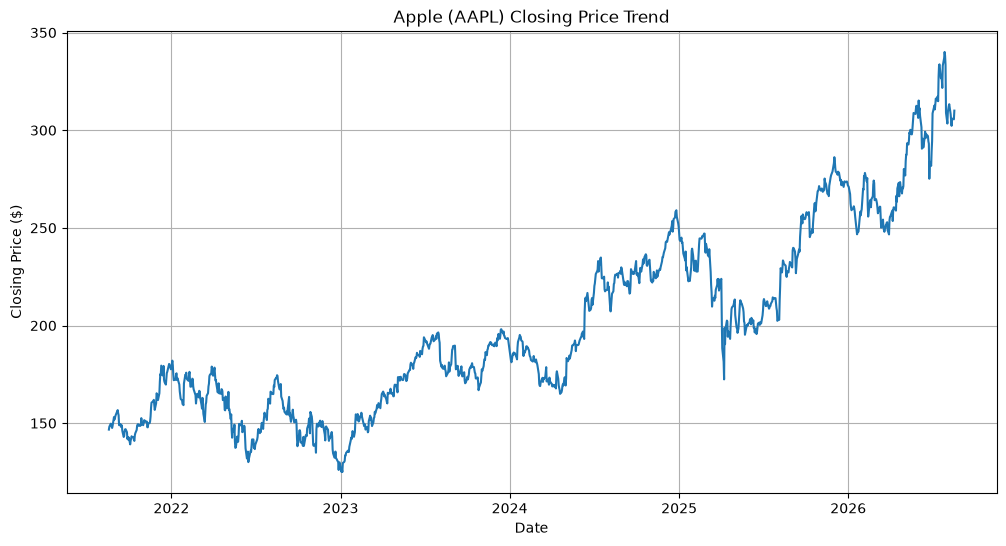

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(aapl.index, aapl['Close'])
plt.title('Apple (AAPL) Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.grid(True)
plt.show()

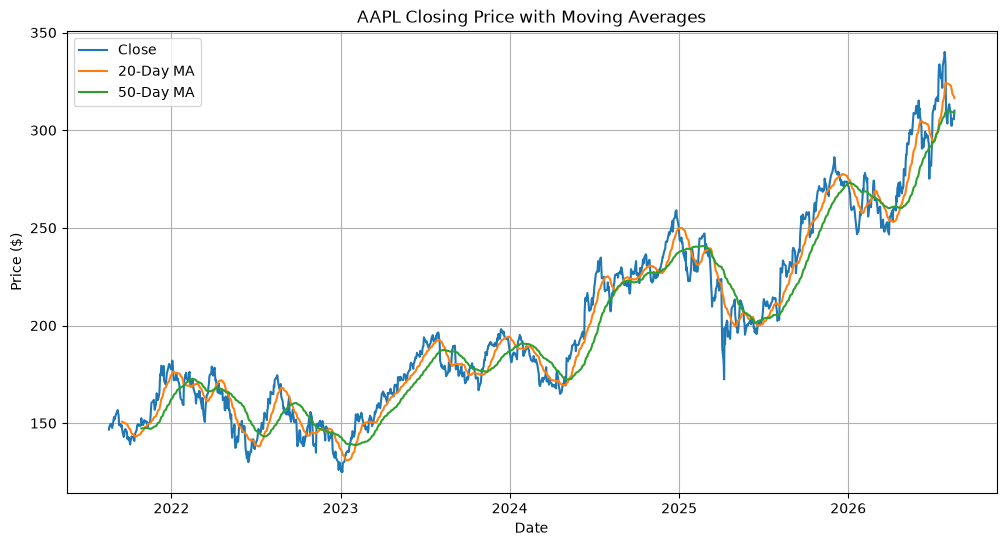

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(aapl.index, aapl['Close'], label='Close')
plt.plot(aapl.index, aapl['MA_20'], label='20-Day MA')
plt.plot(aapl.index, aapl['MA_50'], label='50-Day MA')

plt.title('AAPL Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

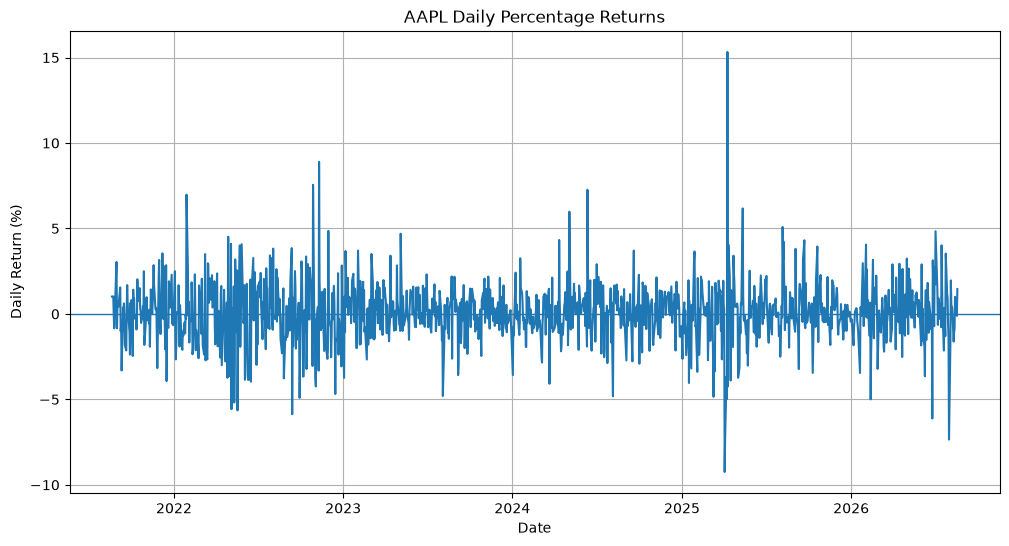

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(aapl.index, aapl['Daily_Return'])
plt.axhline(0, linewidth=1)

plt.title('AAPL Daily Percentage Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True)
plt.show()

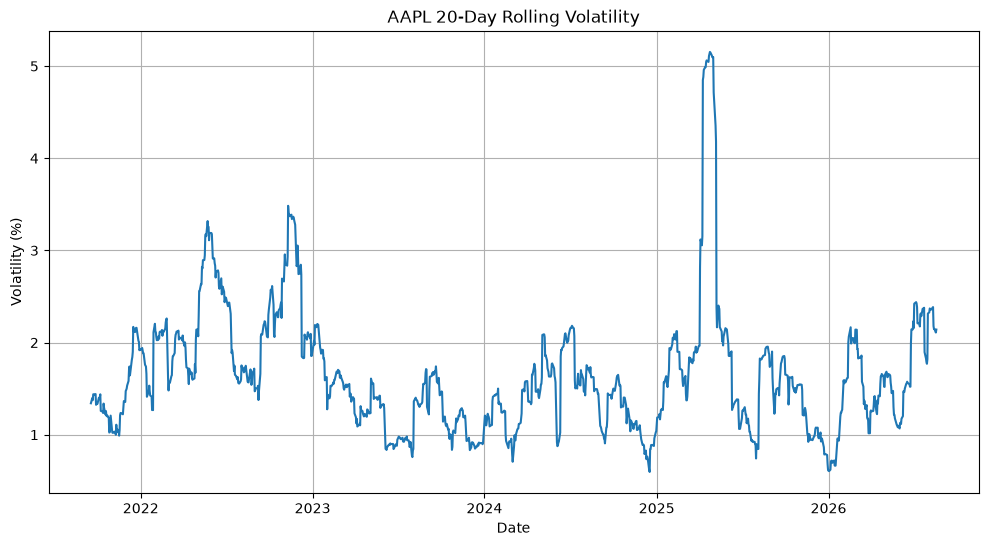

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(aapl.index, aapl['Rolling_Volatility'])

plt.title('AAPL 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.grid(True)
plt.show()